In [38]:
#%%
import math
import numpy as np
import inspect
import importlib

import scipy.interpolate

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

path_to_save_svg = "Saved_Data"



In [39]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [40]:
######################
# Silicon specs
######################

F_mm2_65nm = 14 # gCO2eq/mm2

A_mm2_acc = np.array([0.01, 0.1, 1, 10])  # mm2


# Calculate accelerator embodied footprint for each area
F_65nm_range = A_mm2_acc * F_mm2_65nm

In [41]:
######################
# Application specs
######################

T_years = 10 #years
T_s     = T_years*365*24*60*60 #seconds

E_fft_pt = 4.5e-9          # [J/pt]
Ch_fft_pt = E_fft_pt / 1.2 # [As/pt] @1.2V

R_fft_pt_range = np.logspace(1, 7, 100)  # 10^1 to 10^7 pt/s, 100 points

P_fft_A_range = R_fft_pt_range *  E_fft_pt  # [A] 

In [42]:
######################
# Supply scheme AA cells
######################


F_mAh = 0.06               # [gCo2eq/mAh]
F_ch  = F_mAh * 1000 /3600 # [gCo2eq/As] 

In [43]:
######################
# Supply scheme PV + Super cap
######################

F_solar_load_per_w = 420 # [gCO2eq/W] 

F_solar_load_per_A = F_solar_load_per_w / 1.2  # [gCO2eq/A] 

In [44]:
######################
# Supply scheme grid
######################

F_grid_load_per_kwh = 442 # [gCO2eq/kWh] 

F_grid_load_per_As = F_grid_load_per_kwh / 1.2 /3600 /1000  # [gCO2eq/As] 

print(f'Grid load per As: {F_grid_load_per_As} gCO2eq/As')

Grid load per As: 0.00010231481481481483 gCO2eq/As


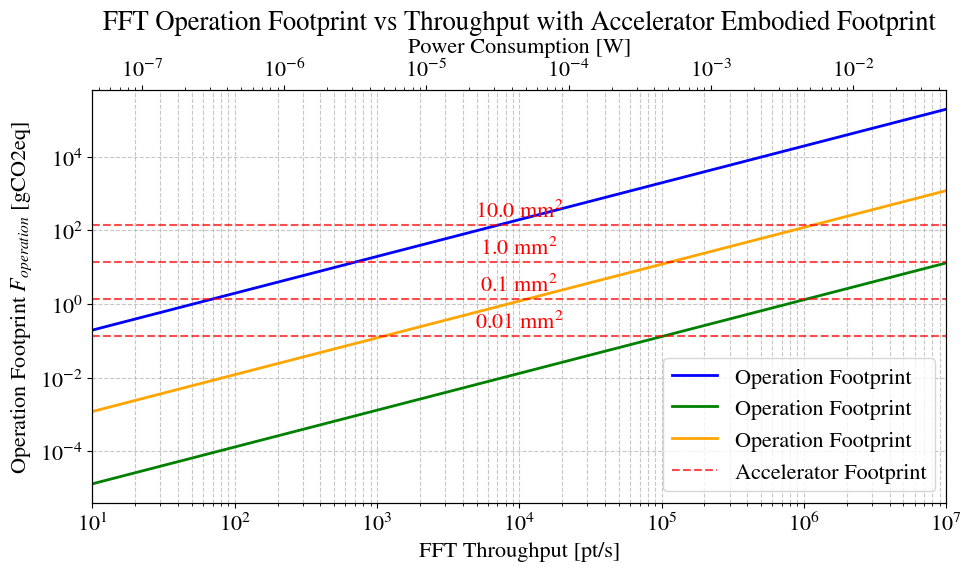

In [45]:
# Calculate F_operation for each throughput value
F_alk_operation_range = F_ch * Ch_fft_pt * R_fft_pt_range * T_s

F_pv_operation_range = F_solar_load_per_A * Ch_fft_pt * R_fft_pt_range

F_grid_operation_range = F_grid_load_per_As * Ch_fft_pt * R_fft_pt_range * T_s

# Plot the operation footprint vs FFT throughput
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.loglog(R_fft_pt_range, F_alk_operation_range, 'b', linewidth=2, label='Operation Footprint')
ax1.loglog(R_fft_pt_range, F_pv_operation_range,  'g', linewidth=2, label='Operation Footprint')
ax1.loglog(R_fft_pt_range, F_grid_operation_range,'orange', linewidth=2, label='Operation Footprint')

ax1.set_xlabel('FFT Throughput [pt/s]')
ax1.set_ylabel('Operation Footprint $F_{operation}$ [gCO2eq]')
ax1.set_title('FFT Operation Footprint vs Throughput with Accelerator Embodied Footprint')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)
ax1.set_xlim(10, 1e7)

# Add second x-axis for power consumption
ax2 = ax1.twiny()
P_fft_W_range = R_fft_pt_range * E_fft_pt  # [W] Power consumption
ax2.set_xlim(10 * E_fft_pt, 1e7 * E_fft_pt)
ax2.set_xlabel('Power Consumption [W]')
ax2.set_xscale('log')

# Add horizontal dashed lines for accelerator embodied footprint with text labels
for F_65nm, A_mm2 in zip(F_65nm_range, A_mm2_acc):
    ax1.axhline(y=F_65nm, color='r', linestyle='--', alpha=0.7, label=f'Accelerator Footprint' if A_mm2 == 0.01 else '')
    ax1.text(1e4, F_65nm * 1.2, f'{A_mm2} mm$^2$', color='r', ha='center', va='bottom')

# Add legend
ax1.legend()
fig.tight_layout()
plt.show()


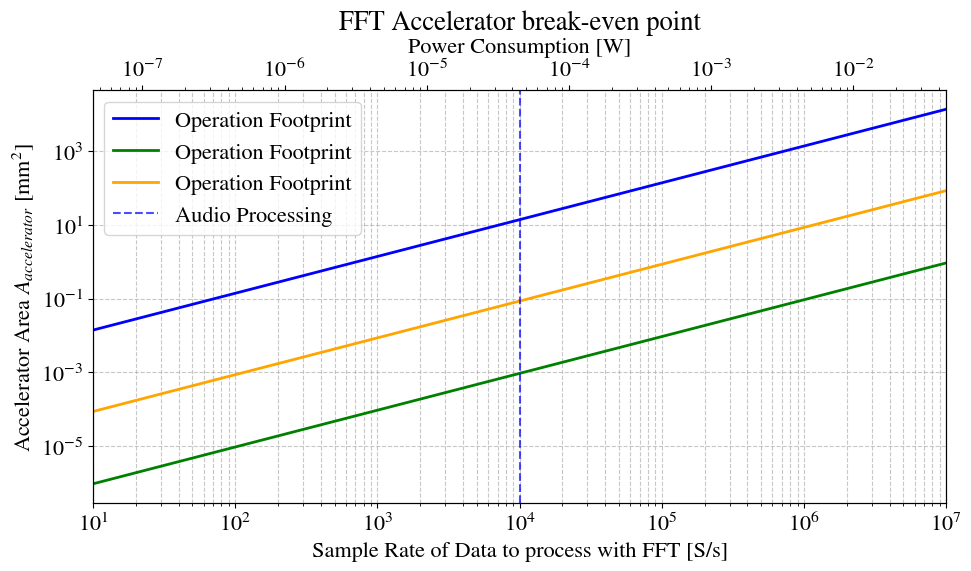

In [55]:
# Area of accelerator for break-even point (F_operation = F_embodied)
A_alk_operation_range  =  (F_ch * Ch_fft_pt * R_fft_pt_range * T_s)     / F_mm2_65nm

A_pv_operation_range   =  (F_solar_load_per_A * Ch_fft_pt * R_fft_pt_range)     / F_mm2_65nm

A_grid_operation_range =  (F_grid_load_per_As * Ch_fft_pt * R_fft_pt_range * T_s)       / F_mm2_65nm

# Plot the operation footprint vs FFT throughput
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.loglog(R_fft_pt_range, A_alk_operation_range, 'b', linewidth=2, label='Operation Footprint')
ax1.loglog(R_fft_pt_range, A_pv_operation_range,  'g', linewidth=2, label='Operation Footprint')
ax1.loglog(R_fft_pt_range, A_grid_operation_range,'orange', linewidth=2, label='Operation Footprint')

ax1.set_xlabel('Sample Rate of Data to process with FFT [S/s]')
ax1.set_ylabel('Accelerator Area $A_{accelerator}$ [mm$^2$]')
ax1.set_title('FFT Accelerator break-even point')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)
ax1.set_xlim(10, 1e7)

# Add second x-axis for power consumption
ax2 = ax1.twiny()
P_fft_W_range = R_fft_pt_range * E_fft_pt  # [W] Power consumption
ax2.set_xlim(10 * E_fft_pt, 1e7 * E_fft_pt)
ax2.set_xlabel('Power Consumption [W]')
ax2.set_xscale('log')


ax1.axvline(x=10e3, color='b', linestyle='--', alpha=0.7, label='Audio Processing')

# Add legend
ax1.legend()
fig.tight_layout()
plt.show()
